# Erasmus KA1 Mobility Analysis – Imputation & Destination Modeling

This notebook picks up where `dataProcessing.ipynb` leaves off and aims at discovering wheter it is possible to predict where a student will go based on the dataset.

The idea is to use the features to train a **supervised model that predicts the Receiving Country** of an exchange, given the participant's profile. In essence, a destination "recommender".

In [122]:
import gc
import pandas as pd
import numpy as np
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import train_test_split, RandomizedSearchCV, HalvingRandomSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

import re
import warnings


warnings.filterwarnings('ignore')
pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 20)
#pd.set_option('future.infer_string', False)

In [123]:
RAW_PATH = 'Datasets/Processed/Erasmus-Data.csv'
df = pd.read_csv(RAW_PATH, index_col=0)
print('Loaded:', df.shape)
df.head()

Loaded: (3172958, 14)


,Academic Year,Mobility Duration,Field of Education,Participant Country,Education Level,Participant Gender,Fewer Opportunities,Participant Age,Sending Country,Sending City,Sending Organization,Receiving Country,Receiving City,Receiving Organization
1358,2023,61,Business and administration,Austria,ISCED-6 - First cycle / Bachelor’s or equivale...,Female,0,22,Austria,WIEN,WU,Germany,Munich,-
1359,2023,101,Economics,Germany,ISCED-7 - Second cycle / Master’s or equivalen...,Male,0,27,Austria,WIEN,WU,France,Toulouse,Université Toulouse Capitole
1360,2023,121,Business and administration,Austria,ISCED-6 - First cycle / Bachelor’s or equivale...,Female,0,22,Austria,WIEN,WU,France,Paris,-
1361,2023,171,Business and administration,Germany,ISCED-6 - First cycle / Bachelor’s or equivale...,Male,0,22,Austria,WIEN,WU,France,Paris,-
1365,2023,86,Business and administration,Austria,ISCED-6 - First cycle / Bachelor’s or equivale...,Male,0,23,Austria,WIEN,WU,Germany,Hamburg,-


## 1. Looking for missing data

There exists invalid entries: some simply report a `?`, others `na`, a handful of rows have `Mobility Duration <= 0` etc...
these cannot be a real value and should be treated as missing. Rather than dropping them, like we did before, why don't we try to impute them?

In [124]:
MISSING_TOKENS = {'-', '--', '???', '??', 'n/a', 'na', 'null', 'none', 'unknown', 'nan', ''}

def normalize_missing(series):
    """Treat placeholder strings (any casing/whitespace) as NaN."""
    s = series.astype('string').str.strip()
    is_missing = s.str.lower().isin(MISSING_TOKENS)
    return s.mask(is_missing, pd.NA)

obj_cols = df.select_dtypes(include=['object', 'string']).columns
for c in obj_cols:
    df[c] = normalize_missing(df[c])

print('Missing values once placeholders are normalized to NaN:')
print(df.isna().sum()[df.isna().sum() > 0])

Missing values once placeholders are normalized to NaN:
Field of Education           129
Participant Country         2316
Fewer Opportunities       180613
Sending Organization      107238
Receiving City              5752
Receiving Organization    223319
dtype: int64


In [125]:
null_duration = (df['Mobility Duration'] <= 0).sum()
df.loc[df['Mobility Duration'] <= 0, 'Mobility Duration'] = pd.NA
print(f'Invalidated {null_duration} non-positive Mobility Duration values -> NaN')

Invalidated 23678 non-positive Mobility Duration values -> NaN


### 1.1. Standardizing categories (even more than in the other notebook)


In [126]:
# Fewer Opportunities: unify Yes/No/1/0 encodings
fo_map = {'yes': 'Yes', 'no': 'No', '1': 'Yes', '0': 'No'}
df['Fewer Opportunities'] = df['Fewer Opportunities'].str.strip().str.lower().map(fo_map)

# Education Level: canonical key = the ISCED-N code
def canon_isced(label):
    if pd.isna(label):
        return np.nan
    m = re.match(r'(ISCED-\d+)', label)
    return m.group(1) if m else label

isced_key = df['Education Level'].map(canon_isced)
canonical_label = (
    df.groupby(isced_key)['Education Level']
    .agg(lambda x: x.value_counts().idxmax())
)
df['Education Level'] = isced_key.map(canonical_label)
print('Education Level canonical values:')
print(df['Education Level'].unique().tolist())

Education Level canonical values:
['ISCED-6 - First cycle / Bachelor’s or equivalent level (EQF-6)', 'ISCED-7 - Second cycle / Master’s or equivalent level (EQF-7)', 'ISCED-8 - Third cycle / Doctoral or equivalent level (EQF-8)', 'ISCED-5 - Short-cycle within the first cycle / Short-cycle tertiary education (EQF-5)', 'ISCED-9 - Not elsewhere classified']


In [127]:
df.head()

,Academic Year,Mobility Duration,Field of Education,Participant Country,Education Level,Participant Gender,Fewer Opportunities,Participant Age,Sending Country,Sending City,Sending Organization,Receiving Country,Receiving City,Receiving Organization
1358,2023,61.0,Business and administration,Austria,ISCED-6 - First cycle / Bachelor’s or equivale...,Female,No,22,Austria,WIEN,WU,Germany,Munich,<NA>
1359,2023,101.0,Economics,Germany,ISCED-7 - Second cycle / Master’s or equivalen...,Male,No,27,Austria,WIEN,WU,France,Toulouse,Université Toulouse Capitole
1360,2023,121.0,Business and administration,Austria,ISCED-6 - First cycle / Bachelor’s or equivale...,Female,No,22,Austria,WIEN,WU,France,Paris,<NA>
1361,2023,171.0,Business and administration,Germany,ISCED-6 - First cycle / Bachelor’s or equivale...,Male,No,22,Austria,WIEN,WU,France,Paris,<NA>
1365,2023,86.0,Business and administration,Austria,ISCED-6 - First cycle / Bachelor’s or equivale...,Male,No,23,Austria,WIEN,WU,Germany,Hamburg,<NA>


## 2. Setting up the classifier


First, set up the imputation rules and all we need to prepare the dataset. Then prepare the model. Lastly, run 3CV on a 80/20 split of the dataset. Enjoy the 1h waiting time for the result. Manual garbage allocation is needed to not make it crash due to RAM usage.

In [ ]:
df['Duration_Months'] = (df['Mobility Duration'] / 30.44).round() # n. o months, kinda

X = df.drop(columns=['Receiving Country', 'Receiving City', 'Receiving Organization'])
y = df['Receiving Country'] 

del df
gc.collect()

# Define your columns
cat_cols = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
print (cat_cols)

# Add your existing numerical columns plus the new engineered ones
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
print (num_cols)

print(f"Detected {len(num_cols)} numerical features and {len(cat_cols)} categorical features.")


K = 15  # number of classes to keep
top_k_classes = y.value_counts().nlargest(K).index
mask = y.isin(top_k_classes).values
 
n_before = len(mask)
X = X.loc[mask]  # no .copy(): avoids duplicating a 3M-row frame in memory
y = y.loc[mask]
print(f"Kept {mask.sum():,}/{n_before:,} rows across {K} classes "
      f"({mask.sum() / n_before:.1%} of data).")
 
del mask
gc.collect()

le = LabelEncoder()
y = le.fit_transform(y)
print(f"Encoded classes (contiguous, matches model): {list(le.classes_)}")

# Precision cut to help with memory
for col in num_cols:
     X[col] = X[col].astype('float32')


for col in cat_cols:
    X[col] = X[col].astype(object).astype('category')

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
 
del X, y
gc.collect()

# Numerical Pipeline
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Categorical Pipeline (Strict order: Impute -> Encode)
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1, max_categories=254))
])

# Combine into ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# Calculate the indices of the categorical features dynamically for HGBC.

cat_feature_indices = list(range(len(num_cols), len(num_cols) + len(cat_cols)))

# Initialize HGBC with native categorical support and balanced class weights
base_hgb = HistGradientBoostingClassifier(
    early_stopping= True,
    max_iter= 1000,
    validation_fraction=0.1,
    n_iter_no_change=5,
    categorical_features=cat_feature_indices,
    #class_weight= 'balanced',
    random_state=42
)

# Create the final unified pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', base_hgb)
])


# 'classifier__' prefix tells RandomizedSearchCV 
# to apply these parameters specifically to the HGBC step inside the pipeline.
param_dist_hgb = {
    'classifier__learning_rate': [0.02, 0.05, 0.1, 0.2],
    #'classifier__max_iter': [100, 200, 300],             
    'classifier__max_leaf_nodes': [31, 63, 127],         
    'classifier__max_depth': [3, 5, 8, None],
    'classifier__min_samples_leaf': [20, 50, 100],       
    'classifier__l2_regularization': [0.0, 0.1]     
}

#random_search = RandomizedSearchCV(
#    estimator=pipeline,
#    param_distributions=param_dist_hgb,
#    n_iter=10,          
#    scoring='f1_weighted', 
#    cv=3,               
#    n_jobs=4,          
#    verbose=2,
#    random_state=42
#)

random_search = HalvingRandomSearchCV(
    estimator=pipeline,
    param_distributions=param_dist_hgb,
    n_candidates=60,       # bumped from 15 -- cheap to explore more here, since
                            # most candidates get eliminated on small subsets
                            # before ever touching the full training set
    factor=3,               # keep best 1/3 of candidates each round, ~3x the
                            # row count for survivors -- sklearn's standard default
    resource='n_samples',   # halve on ROW COUNT per round (the default) -- this
                            # is what actually saves wall-clock time here
    min_resources=50_000,   # explicit floor instead of the default 'smallest'
                            # (~90 rows for 15 classes x cv=3 -- far too noisy
                            # a sample to make elimination decisions on)
    max_resources=500_000,   
    scoring='f1_weighted',
    cv=3,
    n_jobs= 4,          # number of threads,WATCH OUT AT THE END: it spawns n copies of the full dataset, I lost 1h of runtime for that
    verbose=2,
    random_state=42
)


print("Starting training...")
random_search.fit(X_train, y_train)

print(f"Best Parameters: {random_search.best_params_}")
print(f"Best F1 Weighted Score: {random_search.best_score_}")

['Field of Education', 'Participant Country', 'Education Level', 'Participant Gender', 'Fewer Opportunities', 'Sending Country', 'Sending City', 'Sending Organization']
['Academic Year', 'Mobility Duration', 'Participant Age', 'Duration_Months']
Detected 4 numerical features and 8 categorical features.
Kept 2,632,839/3,172,958 rows across 15 classes (83.0% of data).
Encoded classes (contiguous, matches model): ['Austria', 'Belgium', 'Finland', 'France', 'Germany', 'Hungary', 'Ireland', 'Italy', 'Netherlands', 'Norway', 'Poland', 'Portugal', 'Spain', 'Sweden', 'United Kingdom']
Starting training...
n_iterations: 3
n_required_iterations: 4
n_possible_iterations: 3
min_resources_: 50000
max_resources_: 500000
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 60
n_resources: 50000
Fitting 3 folds for each of 60 candidates, totalling 180 fits
----------
iter: 1
n_candidates: 20
n_resources: 150000
Fitting 3 folds for each of 20 candidates, totalling 60 fits
----------

### Class weight active

iter: 0
n_candidates: 60
n_resources: 50000
Fitting 3 folds for each of 60 candidates, totalling 180 fits

iter: 1
n_candidates: 20
n_resources: 150000
Fitting 3 folds for each of 20 candidates, totalling 60 fits

iter: 2
n_resources: 450000
Fitting 3 folds for each of 7 candidates, totalling 21 fits

Best Parameters: {'classifier__min_samples_leaf': 20, 'classifier__max_leaf_nodes': 127, 'classifier__max_depth': None, 'classifier__learning_rate': 0.02, 'classifier__l2_regularization': 0.0}

Best F1 Weighted Score: 0.31367129097354374

### Class Weight inactive

iter: 0
n_candidates: 60
n_resources: 50000
Fitting 3 folds for each of 60 candidates, totalling 180 fits

iter: 1
n_candidates: 20
n_resources: 150000
Fitting 3 folds for each of 20 candidates, totalling 60 fits

iter: 2
n_candidates: 
n_resources: 450000
Fitting 3 folds for each of 7 candidates, totalling 21 fits

Best Parameters: {'classifier__min_samples_leaf': 20, 'classifier__max_leaf_nodes': 127, 'classifier__max_depth': None, 'classifier__learning_rate': 0.02, 'classifier__l2_regularization': 0.0}

Best F1 Weighted Score: 0.345891857929828

In [142]:
# Predict on the test set
y_pred = random_search.predict(X_test)

# Print the detailed breakdown
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.35      0.16      0.22     17215
           1       0.35      0.20      0.25     25002
           2       0.40      0.29      0.34     16483
           3       0.44      0.44      0.44     56960
           4       0.42      0.44      0.43     62875
           5       0.53      0.22      0.31     11926
           6       0.45      0.24      0.32     14939
           7       0.40      0.41      0.40     57635
           8       0.38      0.29      0.33     27363
           9       0.41      0.29      0.34     14965
          10       0.47      0.47      0.47     30991
          11       0.38      0.19      0.25     30954
          12       0.39      0.63      0.48     96222
          13       0.38      0.30      0.34     20722
          14       0.42      0.49      0.45     42316

    accuracy                           0.41    526568
   macro avg       0.41      0.34      0.36    526568
weighted avg       0.41   

Where a European student ends up might be driven by things no dataset captures well: personal preference, that year's specific quota availability, specific universities arrangements. The features we have don't seem capable of closing the gap.

Saved confusion_matrix.png

Top 15 confusion pairs by raw count:
  true_country   predicted_as  count  share_of_true_class
       Germany          Spain  12251                0.195
        France          Spain  11586                0.203
         Italy          Spain  10865                0.189
      Portugal          Spain   9104                0.294
United Kingdom          Spain   7551                0.178
       Belgium          Spain   7335                0.293
         Spain         France   6689                0.070
         Spain        Germany   6390                0.066
   Netherlands          Spain   6242                0.228
        Sweden          Spain   5590                0.270
         Italy        Germany   5505                0.096
       Germany          Italy   5258                0.084
        Poland          Spain   5194                0.168
      Portugal          Italy   5007                0.162
         Spain United Kingdom   4737                0.049

Top 15

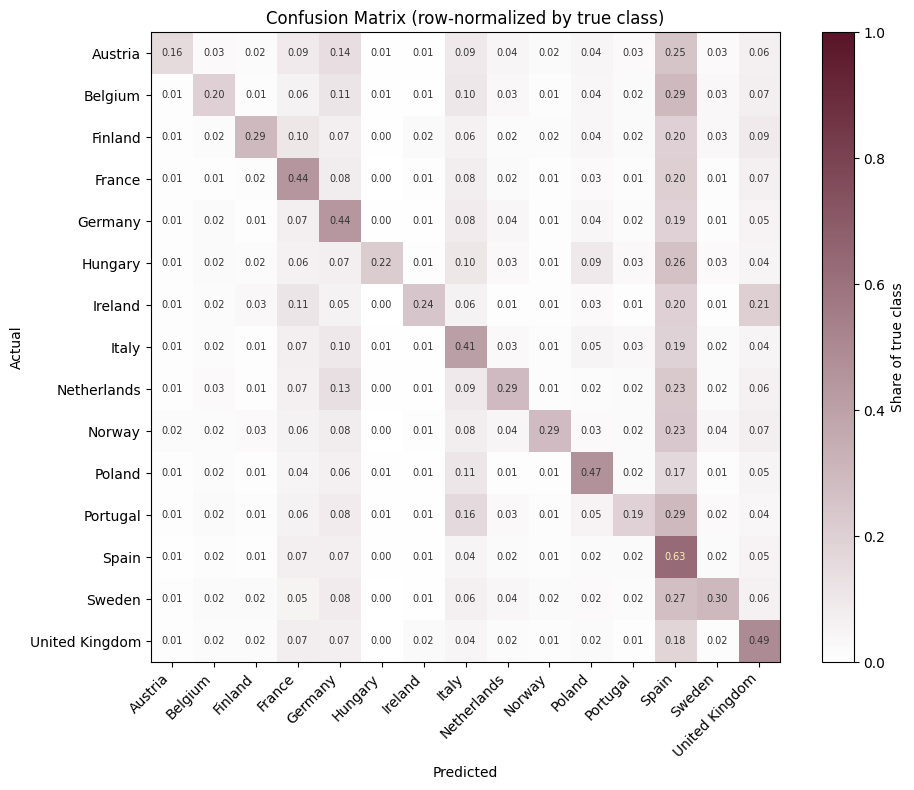

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

maroon_cmap = LinearSegmentedColormap.from_list('maroon_theme', ['white', '#591427'])
labels_present = list(range(len(le.classes_)))
country_names = le.classes_

cm = confusion_matrix(y_test, y_pred, labels=labels_present)
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)
 
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm_normalized, cmap=maroon_cmap, vmin=0, vmax=1)
ax.set_xticks(range(len(country_names)))
ax.set_yticks(range(len(country_names)))
ax.set_xticklabels(country_names, rotation=45, ha='right')
ax.set_yticklabels(country_names)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix (row-normalized by true class)')
fig.colorbar(im, ax=ax, label='Share of true class')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
print("Saved confusion_matrix.png")

# Per cell accuracy on the prediction
for i in range(len(country_names)):
    for j in range(len(country_names)):
        value = cm_normalized[i, j]
        if value > 0:
            ax.text(j, i, f'{value:.2f}', ha='center', va='center',
                     fontsize=7, color='#FFF1B5' if value > 0.5 else '#333333')



# Top confused pairs, excluding the diagonal (correct predictions).
# Sorted two ways: by raw count (biggest absolute problem areas) and by
# share of the true class (classes that are badly confused even if small).
pairs = []
for i, true_code in enumerate(labels_present):
    for j, pred_code in enumerate(labels_present):
        if i != j and cm[i, j] > 0:
            pairs.append({
                'true_country': country_names[i],
                'predicted_as': country_names[j],
                'count': int(cm[i, j]),
                'share_of_true_class': round(float(cm_normalized[i, j]), 3),
            })
pairs_df = pd.DataFrame(pairs)
 
print("\nTop 15 confusion pairs by raw count:")
print(pairs_df.sort_values('count', ascending=False).head(K).to_string(index=False))
 
print("\nTop 15 confusion pairs by share of true class (rate, not volume):")
print(pairs_df.sort_values('share_of_true_class', ascending=False).head(K).to_string(index=False))


Top-1 accuracy: 0.408
Top-3 accuracy: 0.704
Top-5 accuracy: 0.840
Saved topk_accuracy.png


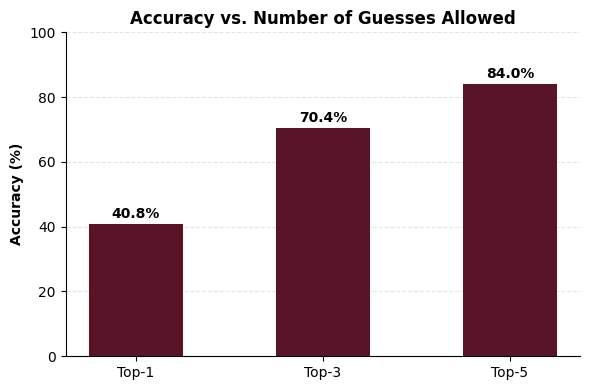

In [144]:
from sklearn.metrics import top_k_accuracy_score
 
y_proba = random_search.predict_proba(X_test)
model_classes = random_search.classes_  # matches y_proba's column order
 
topk_results = {}
for k in [1, 3, 5]:
    topk_results[k] = top_k_accuracy_score(y_test, y_proba, k=k, labels=model_classes)
    print(f"Top-{k} accuracy: {topk_results[k]:.3f}")
 
# Quick visual: how much accuracy is "recovered" by allowing more guesses
fig, ax = plt.subplots(figsize=(6, 4))
ks = list(topk_results.keys())
vals = [topk_results[k] * 100 for k in ks]
bars = ax.bar([f'Top-{k}' for k in ks], vals, color='#591427', width=0.5)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontweight='bold')
ax.set_title('Accuracy vs. Number of Guesses Allowed', fontweight='bold')
ax.set_ylim(0, 100)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#cccccc')
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('topk_accuracy.png', dpi=150)
print("Saved topk_accuracy.png")
plt.show()


RECOMMENDER

In [132]:
def get_erasmus_recommendations(user_profile, model, label_encoder=None, top_k=5):
    """
    Takes a user profile dictionary, the trained pipeline model, 
    and the LabelEncoder instance to return human-readable top recommendations.
    """
    # Convert profile dictionary to DataFrame
    user_df = pd.DataFrame([user_profile])
    
    # Predict probabilities for each numeric class
    probabilities = model.predict_proba(user_df)[0]
    classes = model.classes_  # Array of integer class IDs
    
    # Sort class IDs by probability (highest to lowest)
    ranked = sorted(zip(classes, probabilities), key=lambda x: x[1], reverse=True)
    
    print(f"--- Top {top_k} Recommended Destinations ---")
    results = []
    
    for i, (class_id, prob) in enumerate(ranked[:top_k]):
        # Decode integer class_id using your LabelEncoder instance
        if label_encoder is not None:
            country_name = label_encoder.inverse_transform([class_id])[0]
        else:
            country_name = f"Class {class_id}"
            
        print(f"#{i + 1}: {country_name} (Match Score: {prob:.1%})")
        results.append({
            "Rank": i + 1,
            "Country": country_name,
            "Probability": prob
        })
        
    return results

In [133]:
def plot_erasmus_recommendations(user_profile, model, label_encoder=None, top_k=10):
    """
    Plots a horizontal bar chart showing the predicted probability distribution 
    for the top K recommended destination countries.
    """
    # 1. Format input into a DataFrame and extract probabilities
    user_df = pd.DataFrame([user_profile])
    probabilities = model.predict_proba(user_df)[0]
    classes = model.classes_
    
    # 2. Decode country names if LabelEncoder is provided
    if label_encoder is not None:
        country_names = label_encoder.inverse_transform(classes)
    else:
        country_names = [f"Class {c}" for c in classes]
        
    # 3. Create a DataFrame and sort by probability
    df_probs = pd.DataFrame({
        'Country': country_names,
        'Probability': probabilities * 100  # Convert to percentage
    }).sort_values(by='Probability', ascending=False).head(top_k)
    
    # Reverse order so the #1 country appears at the top of the horizontal bar plot
    df_plot = df_probs.iloc[::-1].reset_index(drop=True)
    
    # 4. Create the plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Highlight the top choice with a distinct color
    colors = ['#591427' if i == len(df_plot) - 1 else '#FFF1B5' for i in range(len(df_plot))]
    bars = ax.barh(df_plot['Country'], df_plot['Probability'], color=colors, edgecolor='none', height=0.65)
    
    # 5. Add percentage labels beside each bar
    for bar in bars:
        width = bar.get_width()
        ax.text(
            width + 0.8, 
            bar.get_y() + bar.get_height() / 2, 
            f'{width:.1f}%', 
            va='center', 
            ha='left', 
            fontsize=10, 
            fontweight='bold', 
            color='#222222'
        )
        
    # 6. Styling and formatting
    ax.set_xlabel('Recommendation Match Score (%)', fontsize=11, labelpad=10, fontweight='bold')
    ax.set_title(f'Top {top_k} Destination Recommendations', fontsize=14, pad=15, fontweight='bold')
    
    # Add buffer to the right axis so text labels don't get cut off
    max_val = df_plot['Probability'].max()
    ax.set_xlim(0, max_val + (max_val * 0.25 if max_val > 0 else 10))
    
    # Clean up grid lines and borders
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')
    ax.xaxis.grid(True, linestyle='--', alpha=0.5, color='#cccccc')
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    plt.show()

In [134]:
# Example students
user_1 = {
    'Academic Year': 2016,
    'Mobility Duration': 121,
    'Field of Education': 'Arts',
    'Participant Country': 'France',
    'Education Level': 'ISCED-7 - Second cycle / Master’s or equivalent level (EQF-7)',
    'Participant Gender': 'Male',
    'Fewer Opportunities': 'Yes',
    'Participant Age': 25,
    'Sending Country': 'France',
    'Sending City': 'METZ',
    'Sending Organization': "Ecole Supérieure d'Art de Lorraine",
    'Is_Expat_Student': 0,
    'Duration_Months': 4.0
}

# --- Example 2: Bachelor's Chemistry Student from Belgium ---
user_2 = {
    'Academic Year': 2019,
    'Mobility Duration': 42,
    'Field of Education': 'Chemistry',
    'Participant Country': 'Belgium',
    'Education Level': 'ISCED-6 - First cycle / Bachelor’s or equivalent level (EQF-6)',
    'Participant Gender': 'Male',
    'Fewer Opportunities': 'No',
    'Participant Age': 31,
    'Sending Country': 'Belgium',
    'Sending City': 'Geel',
    'Sending Organization': 'THOMAS MORE KEMPEN VZW',
    'Is_Expat_Student': 0,
    'Duration_Months': 1.0
}

# --- Example 3: Master's Business Student from France ---
user_3 = {
    'Academic Year': 2017,
    'Mobility Duration': 139,
    'Field of Education': 'Business and administration',
    'Participant Country': 'France',
    'Education Level': 'ISCED-7 - Second cycle / Master’s or equivalent level (EQF-7)',
    'Participant Gender': 'Male',
    'Fewer Opportunities': 'No',
    'Participant Age': 24,
    'Sending Country': 'France',
    'Sending City': 'BELFORT',
    'Sending Organization': "ASSOCIATION POUR LA GESTION DE L'ECOLE SUPERIEURE DES TECHNOLOGIES ET DES AFFAIRES",
    'Is_Expat_Student': 0,
    'Duration_Months': 5.0
}

In [ ]:
# Generate recommendations for User 1
print("Recommendations for User 1:")
shortlist_1 = get_erasmus_recommendations(user_profile=user_1, model=random_search, label_encoder = le, top_k=5)

print("\n" + "="*40 + "\n")

# Generate recommendations for User 2
print("Recommendations for User 2:")
shortlist_2 = get_erasmus_recommendations(user_profile=user_2, model=random_search, label_encoder = le, top_k=5)

Recommendations for User 1:
--- Top 5 Recommended Destinations ---
#1: Belgium (Match Score: 25.0%)
#2: Poland (Match Score: 18.1%)
#3: Germany (Match Score: 15.9%)
#4: Italy (Match Score: 9.6%)
#5: United Kingdom (Match Score: 7.9%)


Recommendations for User 2:
--- Top 5 Recommended Destinations ---
#1: Spain (Match Score: 23.0%)
#2: France (Match Score: 22.7%)
#3: United Kingdom (Match Score: 18.4%)
#4: Netherlands (Match Score: 8.2%)
#5: Poland (Match Score: 4.7%)


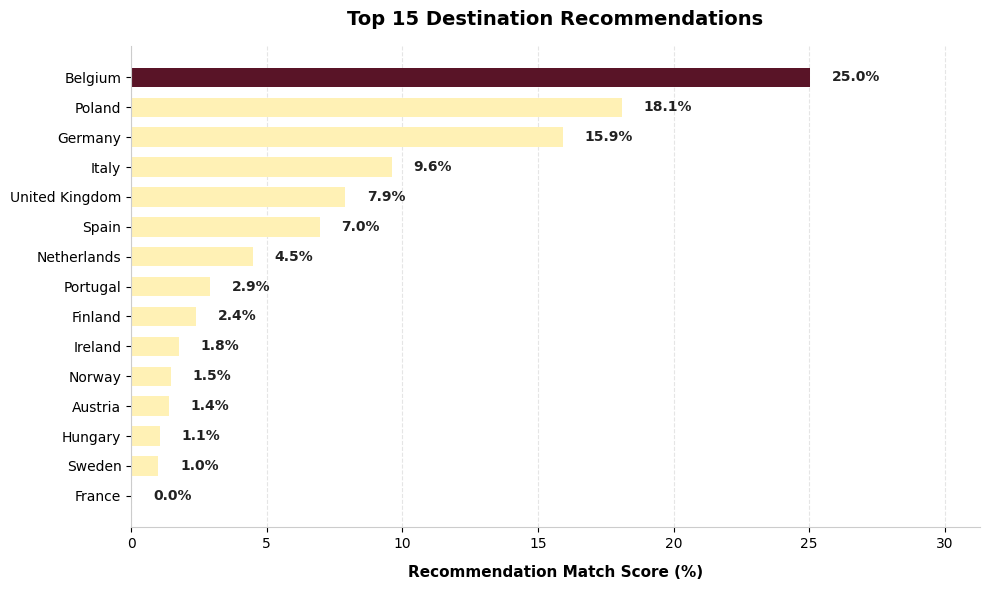

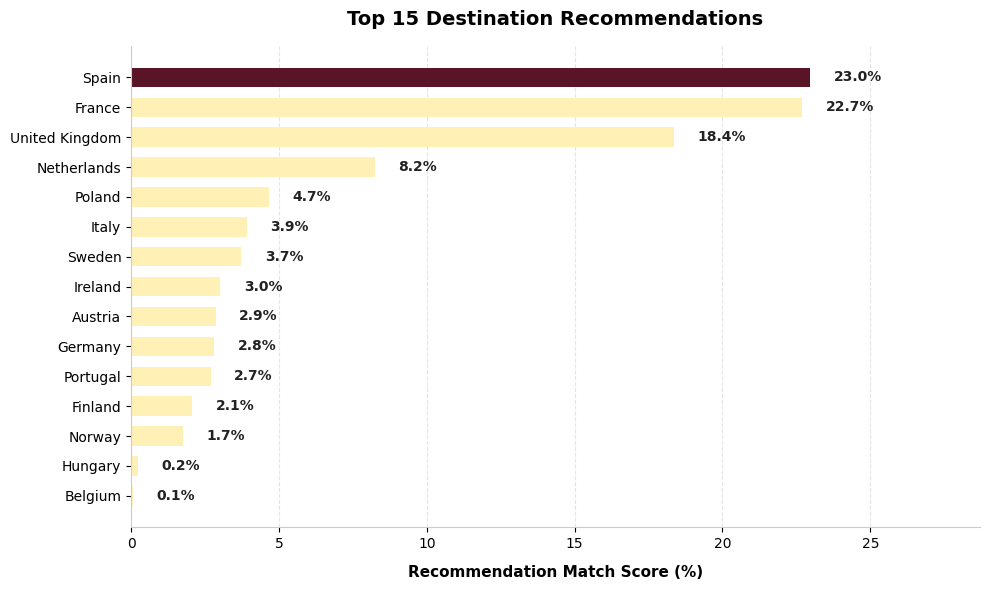

In [136]:
# Visualize the top 10 recommended countries for User 1
plot_erasmus_recommendations(
    user_profile=user_1, 
    model=random_search, 
    label_encoder=le, 
    top_k=15
)

plot_erasmus_recommendations(
    user_profile=user_2, 
    model=random_search, 
    label_encoder=le, 
    top_k=15
)